# Nutty Percept - Olfactory Receptor Association Analysis

This notebook analyzes the relationship between the "nutty" percept and predicted olfactory receptor (OR) activations.

**Analysis Goals:**
1. Identify all molecules with the "nutty" percept label in Goodscents-Leffingwell
2. Identify common receptors predicted to be activated by nutty molecules
3. For molecules predicted to bind these "nutty-associated" receptors, calculate what proportion have the nutty label
4. Perform ablation analysis: if we mask the nutty-associated receptors, does model performance on nutty prediction change?

**Note:** This analysis uses the same OR logits as other OR-percept studies in this repository (`full_weighted_1237_ORs_logits.pt` for M2OR or `weighted_loss_olfactory_subgenome_OR_logits.pt` for HORDE).

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import sys

# Add parent directory to path
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Load Goodscents-Leffingwell Dataset and Identify Nutty Molecules

In [2]:
# Load the GS_LF dataset
gs_lf_path = '../data/datasets/NaNs_GS_LF_isomeric_SMILES_dedup_odor_filtered.csv'
df = pd.read_csv(gs_lf_path)

print(f"Total molecules in GS_LF: {len(df)}")
print(f"\nColumns in dataset: {df.columns.tolist()[:20]}...")  # First 20 columns
print(f"\nTotal number of percept labels: {len(df.columns) - 6}")  # Subtract metadata columns

Total molecules in GS_LF: 5862

Columns in dataset: ['IsomericSMILES', 'Stimulus', 'bland', 'chemical', 'rummy', 'vetiver', 'orangeflower', 'lactonic', 'jammy', 'raspberry', 'minty', 'cooked', 'estery', 'amber', 'terpenic', 'bergamot', 'marine', 'celery', 'jasmin', 'cedar']...

Total number of percept labels: 152


In [3]:
# Check if 'nutty' is in the columns
percept_cols = [c for c in df.columns if c not in ['IsomericSMILES', 'Stimulus', 'IUPACName', 'name', 'CID', 'MolecularWeight']]
print(f"Number of percept columns: {len(percept_cols)}")
print(f"\n'nutty' in percept columns: {'nutty' in percept_cols}")

# Find nutty molecules
nutty_mask = df['nutty'] == 1
nutty_molecules = df[nutty_mask]
non_nutty_molecules = df[~nutty_mask]

print(f"\nNumber of molecules with 'nutty' label: {len(nutty_molecules)}")
print(f"Number of molecules without 'nutty' label: {len(non_nutty_molecules)}")
print(f"Proportion of nutty molecules: {len(nutty_molecules)/len(df)*100:.2f}%")

Number of percept columns: 152

'nutty' in percept columns: True

Number of molecules with 'nutty' label: 366
Number of molecules without 'nutty' label: 5496
Proportion of nutty molecules: 6.24%


In [4]:
# Display some example nutty molecules
print("Example nutty molecules:")
nutty_molecules[['IsomericSMILES', 'name', 'CID']].head(10)

Example nutty molecules:


,IsomericSMILES,name,CID
4,C1=CC=C(C=C1)C=O,benzaldehyde,240.0
9,CC1=CC(=CC=C1)OC,3-methylanisole,7530.0
15,CCCCCCCCCCCC(=O)OC1=CC=C(C=C1)C,p-tolyl laurate,61434.0
20,C1=CNC(=C1)C=O,1h-pyrrole-2-carbaldehyde,13854.0
63,CCCCCCCCCC(=O)OCCC1=C(N=CS1)C,2-(4-methyl-5-thiazolyl)ethyl decanoate,44182035.0
64,CC1NC(SC(S1)CC(C)C)C,101517-87-7,529056.0
79,CCC(C)C(=O)/C=C/C,5-methyl-2-hepten-4-one,5362588.0
121,CC1=CC=C(C=C1)CC=O,104-09-6,61006.0
138,CCC1=CN=C(C=C1)C,5-ethyl-2-methylpyridine,7728.0
139,CC1=CC=C(C=C1)OC,4-methylanisole,7731.0


## 2. Load OR Activation Predictions

We'll load the pre-computed OR logits from the trained MolOR model. These represent the predicted activation of each OR for each molecule in GS_LF.

**Using same logits as other OR-percept studies:**
- M2OR: `full_weighted_1237_ORs_logits.pt` (1237 ORs from matched odorant-OR pairs)
- HORDE: `weighted_loss_olfactory_subgenome_OR_logits.pt` (845 human ORs)

In [5]:
# Choose which OR database to use (same as other OR-percept studies)
OR_DATABASE = 'M2OR'  # Options: 'M2OR' (1237 ORs) or 'HORDE' (845 ORs)

if OR_DATABASE == 'M2OR':
    # M2OR database - 1237 ORs from matched odorant-OR pairs (used in figures_OR_percept.ipynb)
    logits_path = '../data/datasets/full_weighted_1237_ORs_logits.pt'
    or_logits = torch.load(logits_path)
    n_ors = 1237
    # Load M2OR sequence info for OR names
    mol_OR = pd.read_csv('../data/datasets/M2OR_original_mol_OR_pairs.csv', sep=';')
    or_names = mol_OR['seq_id'].value_counts().head(n_ors).index.tolist()
else:
    # HORDE database - 845 human ORs (olfactory subgenome)
    logits_path = '../data/datasets/weighted_loss_olfactory_subgenome_OR_logits.pt'
    or_logits = torch.load(logits_path)
    n_ors = 845
    # Load HORDE gene information for OR names
    genes_df = pd.read_csv('../data/datasets/genes.csv', sep='\t')
    or_names = genes_df['Symbol'].value_counts().head(n_ors).index.tolist()

# Move to CPU if on GPU
if or_logits.is_cuda:
    or_logits = or_logits.cpu()

print(f"OR Database: {OR_DATABASE}")
print(f"OR logits shape: {or_logits.shape}")
print(f"Number of molecules: {or_logits.shape[0]}")
print(f"Number of ORs: {or_logits.shape[1]}")
print(f"\nFirst 10 OR names: {or_names[:10]}")

OR Database: M2OR
OR logits shape: torch.Size([5862, 1237])
Number of molecules: 5862
Number of ORs: 1237

First 10 OR names: ['s_29', 's_51', 's_40', 's_418', 's_1107', 's_110', 's_1108', 's_670', 's_1126', 's_1115']


In [6]:
# Convert logits to binary predictions (using sigmoid threshold of 0.5)
# This is consistent with how OR predictions are used in classification_OR_feat_ESM.py (line 326)
or_probs = torch.sigmoid(or_logits)
or_preds = torch.round(or_probs)  # Same as (or_probs > 0.5).float()

or_activation_rates = or_preds.mean(dim=0)
non_promiscuous_mask = or_activation_rates <= 0.30
n_removed = (~non_promiscuous_mask).sum().item()
print(f"Filtering out ORs with >30% activation rate across GS-LF molecules")
print(f"ORs removed: {n_removed}")
print(f"ORs remaining: {non_promiscuous_mask.sum().item()}")

# Apply filter
or_preds = or_preds[:, non_promiscuous_mask]
or_probs = or_probs[:, non_promiscuous_mask]
or_names = [name for name, keep in zip(or_names, non_promiscuous_mask.tolist()) if keep]

print(f"\nOR predictions shape after filtering: {or_preds.shape}")
print(f"Mean activation probability per molecule: {or_probs.mean().item():.4f}")
print(f"Mean number of ORs activated per molecule: {or_preds.sum(dim=1).mean().item():.2f}")

Filtering out ORs with >30% activation rate across GS-LF molecules
ORs removed: 215
ORs remaining: 1022

OR predictions shape after filtering: torch.Size([5862, 1022])
Mean activation probability per molecule: 0.1385
Mean number of ORs activated per molecule: 111.32


## 3. Identify Receptors Commonly Activated by Nutty Molecules

In [7]:
# Get indices of nutty molecules
nutty_indices = df[df['nutty'] == 1].index.tolist()
non_nutty_indices = df[df['nutty'] == 0].index.tolist()

print(f"Nutty molecule indices: {len(nutty_indices)}")
print(f"Non-nutty molecule indices: {len(non_nutty_indices)}")

Nutty molecule indices: 366
Non-nutty molecule indices: 5496


In [8]:
# Calculate activation frequency for each OR among nutty vs non-nutty molecules
nutty_or_preds = or_preds[nutty_indices]
non_nutty_or_preds = or_preds[non_nutty_indices]

# Activation rate for each OR
nutty_activation_rate = nutty_or_preds.mean(dim=0).numpy()
non_nutty_activation_rate = non_nutty_or_preds.mean(dim=0).numpy()

# Difference in activation rate (nutty - non-nutty)
activation_diff = nutty_activation_rate - non_nutty_activation_rate

print(f"Mean OR activation rate for nutty molecules: {nutty_activation_rate.mean():.4f}")
print(f"Mean OR activation rate for non-nutty molecules: {non_nutty_activation_rate.mean():.4f}")

Mean OR activation rate for nutty molecules: 0.1126
Mean OR activation rate for non-nutty molecules: 0.1087


In [9]:
# Create a DataFrame with OR activation statistics
or_stats = pd.DataFrame({
    'OR_index': range(or_preds.shape[1]),
    'OR_name': or_names[:or_preds.shape[1]] if len(or_names) >= or_preds.shape[1] else [f'OR_{i}' for i in range(or_preds.shape[1])],
    'nutty_activation_rate': nutty_activation_rate,
    'non_nutty_activation_rate': non_nutty_activation_rate,
    'activation_diff': activation_diff
})

# Sort by activation difference (higher = more specific to nutty)
or_stats_sorted = or_stats.sort_values('activation_diff', ascending=False)

print("Top 20 ORs most associated with nutty percept (by activation difference):")
print(or_stats_sorted.head(20))

Top 20 ORs most associated with nutty percept (by activation difference):
     OR_index OR_name  nutty_activation_rate  non_nutty_activation_rate  \
996       996   s_953               0.631148                   0.276747   
3           3  s_1108               0.437158                   0.140466   
765       765   s_756               0.368852                   0.088792   
53         53    s_52               0.352459                   0.081150   
529       529  s_1106               0.505464                   0.282933   
157       157   s_235               0.450820                   0.236536   
211       211  s_1140               0.374317                   0.175946   
401       401   s_438               0.407104                   0.213246   
888       888   s_532               0.407104                   0.215975   
652       652   s_835               0.352459                   0.171397   
219       219  s_1136               0.374317                   0.195961   
78         78   s_207     

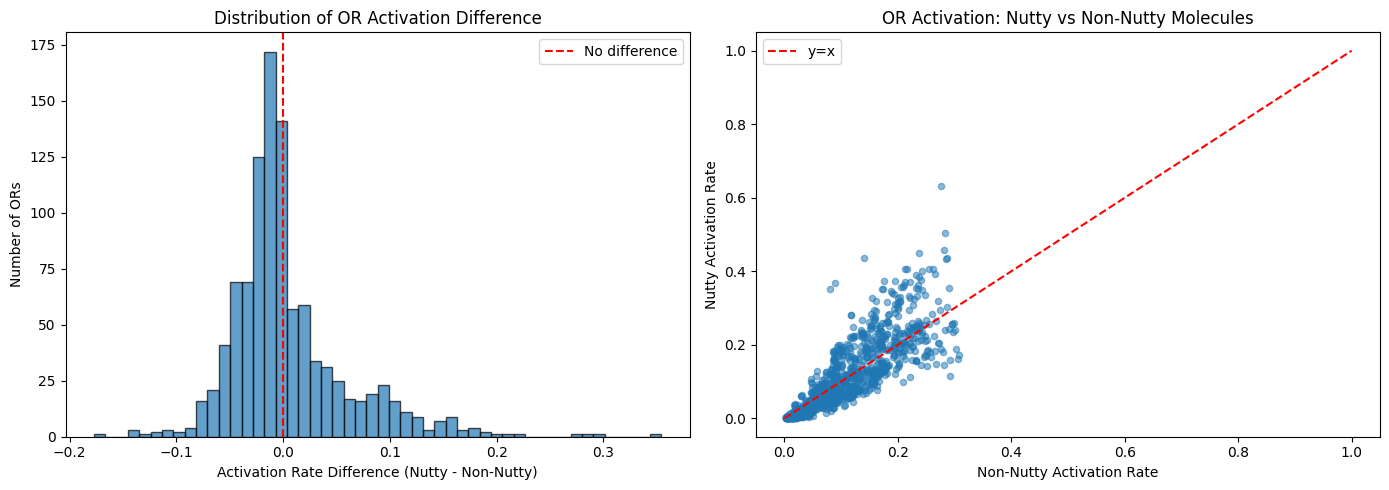

In [10]:
# Visualize activation rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of activation differences
axes[0].hist(activation_diff, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='No difference')
axes[0].set_xlabel('Activation Rate Difference (Nutty - Non-Nutty)')
axes[0].set_ylabel('Number of ORs')
axes[0].set_title('Distribution of OR Activation Difference')
axes[0].legend()

# Scatter plot of activation rates
axes[1].scatter(non_nutty_activation_rate, nutty_activation_rate, alpha=0.5, s=20)
axes[1].plot([0, 1], [0, 1], 'r--', label='y=x')
axes[1].set_xlabel('Non-Nutty Activation Rate')
axes[1].set_ylabel('Nutty Activation Rate')
axes[1].set_title('OR Activation: Nutty vs Non-Nutty Molecules')
axes[1].legend()

plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/nutty_or_activation_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Define "Nutty-Associated" Receptors

We'll identify ORs that are significantly more activated by nutty molecules compared to non-nutty molecules.

In [11]:
# Statistical test: Fisher's exact test for each OR
from scipy.stats import fisher_exact, chi2_contingency

p_values = []
odds_ratios = []

for or_idx in range(or_preds.shape[1]):
    # Create contingency table
    # [nutty & OR_on, nutty & OR_off]
    # [non_nutty & OR_on, non_nutty & OR_off]
    nutty_on = nutty_or_preds[:, or_idx].sum().item()
    nutty_off = len(nutty_indices) - nutty_on
    non_nutty_on = non_nutty_or_preds[:, or_idx].sum().item()
    non_nutty_off = len(non_nutty_indices) - non_nutty_on
    
    table = [[nutty_on, nutty_off], [non_nutty_on, non_nutty_off]]
    
    try:
        odds_ratio, p_value = fisher_exact(table, alternative='greater')
    except:
        odds_ratio, p_value = np.nan, 1.0
    
    p_values.append(p_value)
    odds_ratios.append(odds_ratio)

or_stats['p_value'] = p_values
or_stats['odds_ratio'] = odds_ratios

# Bonferroni correction
or_stats['p_value_corrected'] = or_stats['p_value'] * or_preds.shape[1]
or_stats['p_value_corrected'] = or_stats['p_value_corrected'].clip(upper=1.0)

print(f"Number of ORs with p < 0.05 (uncorrected): {(or_stats['p_value'] < 0.05).sum()}")
print(f"Number of ORs with p < 0.05 (Bonferroni corrected): {(or_stats['p_value_corrected'] < 0.05).sum()}")

Number of ORs with p < 0.05 (uncorrected): 220
Number of ORs with p < 0.05 (Bonferroni corrected): 117


In [12]:
# Define nutty-associated ORs using multiple criteria
# Criterion 1: Activation difference > threshold
# Criterion 2: p-value < 0.05 (corrected)
# Criterion 3: Activation rate in nutty molecules > some minimum

activation_diff_threshold = 0.05  # OR must be at least 5% more activated in nutty
min_nutty_activation = 0.1  # OR must be activated in at least 10% of nutty molecules

nutty_associated_mask = (
    (or_stats['activation_diff'] > activation_diff_threshold) & 
    (or_stats['nutty_activation_rate'] > min_nutty_activation) &
    (or_stats['p_value_corrected'] < 0.05)
)

nutty_associated_ors = or_stats[nutty_associated_mask]
print(f"Number of nutty-associated ORs (strict criteria): {len(nutty_associated_ors)}")

# Also try less strict criteria
nutty_associated_mask_relaxed = (
    (or_stats['activation_diff'] > 0.02) & 
    (or_stats['nutty_activation_rate'] > 0.05)
)
nutty_associated_ors_relaxed = or_stats[nutty_associated_mask_relaxed]
print(f"Number of nutty-associated ORs (relaxed criteria): {len(nutty_associated_ors_relaxed)}")

Number of nutty-associated ORs (strict criteria): 117
Number of nutty-associated ORs (relaxed criteria): 260


In [13]:
# Display the top nutty-associated ORs
print("\nTop nutty-associated ORs (by activation difference):")
top_nutty_ors = or_stats.sort_values('activation_diff', ascending=False).head(20)
print(top_nutty_ors[['OR_index', 'OR_name', 'nutty_activation_rate', 'non_nutty_activation_rate', 
                     'activation_diff', 'odds_ratio', 'p_value_corrected']])


Top nutty-associated ORs (by activation difference):
     OR_index OR_name  nutty_activation_rate  non_nutty_activation_rate  \
996       996   s_953               0.631148                   0.276747   
3           3  s_1108               0.437158                   0.140466   
765       765   s_756               0.368852                   0.088792   
53         53    s_52               0.352459                   0.081150   
529       529  s_1106               0.505464                   0.282933   
157       157   s_235               0.450820                   0.236536   
211       211  s_1140               0.374317                   0.175946   
401       401   s_438               0.407104                   0.213246   
888       888   s_532               0.407104                   0.215975   
652       652   s_835               0.352459                   0.171397   
219       219  s_1136               0.374317                   0.195961   
78         78   s_207               0.459016  

## 5. For Molecules Predicted to Bind Nutty-Associated Receptors, What Proportion Have Nutty Label?

This is the key analysis: if we perform an *in silico* screen for molecules that bind the "nutty" receptor(s), what percentage of them are actually "nutty"?

In [14]:
# Get indices of top nutty-associated ORs
top_n_ors = 10  # Use top 10 ORs
top_nutty_or_indices = or_stats.sort_values('activation_diff', ascending=False).head(top_n_ors)['OR_index'].tolist()

print(f"Top {top_n_ors} nutty-associated OR indices: {top_nutty_or_indices}")
print(f"Top {top_n_ors} nutty-associated OR names:")
for idx in top_nutty_or_indices:
    print(f"  {idx}: {or_stats.loc[or_stats['OR_index'] == idx, 'OR_name'].values[0]}")

Top 10 nutty-associated OR indices: [996, 3, 765, 53, 529, 157, 211, 401, 888, 652]
Top 10 nutty-associated OR names:
  996: s_953
  3: s_1108
  765: s_756
  53: s_52
  529: s_1106
  157: s_235
  211: s_1140
  401: s_438
  888: s_532
  652: s_835


In [15]:
# For each top nutty-associated OR, find molecules predicted to bind it
results = []
baseline_nutty_prop = len(nutty_molecules) / len(df)

for or_idx in top_nutty_or_indices:
    # Molecules predicted to bind this OR
    binding_mask = or_preds[:, or_idx] == 1
    binding_indices = binding_mask.nonzero(as_tuple=True)[0].numpy()
    
    # Of these, how many have nutty label?
    nutty_labels = df.iloc[binding_indices]['nutty'].values
    n_binding = len(binding_indices)
    n_nutty = nutty_labels.sum()
    prop_nutty = n_nutty / n_binding if n_binding > 0 else 0
    
    results.append({
        'OR_index': or_idx,
        'OR_name': or_stats.loc[or_stats['OR_index'] == or_idx, 'OR_name'].values[0],
        'n_molecules_binding': n_binding,
        'n_nutty': int(n_nutty),
        'proportion_nutty': prop_nutty,
        'enrichment': prop_nutty / baseline_nutty_prop if baseline_nutty_prop > 0 else 0
    })
    
results_df = pd.DataFrame(results)
print(f"Baseline proportion of nutty molecules in dataset: {baseline_nutty_prop:.4f} ({baseline_nutty_prop*100:.2f}%)")
print(f"\nProportion of nutty molecules among those predicted to bind each top nutty-associated OR:")
print(results_df)

Baseline proportion of nutty molecules in dataset: 0.0624 (6.24%)

Proportion of nutty molecules among those predicted to bind each top nutty-associated OR:
   OR_index OR_name  n_molecules_binding  n_nutty  proportion_nutty  \
0       996   s_953                 1752      231          0.131849   
1         3  s_1108                  932      160          0.171674   
2       765   s_756                  623      135          0.216693   
3        53    s_52                  575      129          0.224348   
4       529  s_1106                 1740      185          0.106322   
5       157   s_235                 1465      165          0.112628   
6       211  s_1140                 1104      137          0.124094   
7       401   s_438                 1321      149          0.112793   
8       888   s_532                 1336      149          0.111527   
9       652   s_835                 1071      129          0.120448   

   enrichment  
0    2.111751  
1    2.749595  
2    3.470647

In [16]:
# Summary statistics
print(f"\nMean enrichment factor: {results_df['enrichment'].mean():.2f}x")
print(f"Max enrichment factor: {results_df['enrichment'].max():.2f}x")
print(f"\nBest single OR for nutty screening:")
best_or = results_df.loc[results_df['proportion_nutty'].idxmax()]
print(f"  {best_or['OR_name']} (index {best_or['OR_index']}): {best_or['proportion_nutty']*100:.1f}% nutty ({best_or['enrichment']:.2f}x enrichment)")


Mean enrichment factor: 2.29x
Max enrichment factor: 3.59x

Best single OR for nutty screening:
  s_52 (index 53): 22.4% nutty (3.59x enrichment)


In [17]:
# Molecules predicted to bind ANY of the top nutty-associated ORs
any_nutty_or_binding = or_preds[:, top_nutty_or_indices].sum(dim=1) > 0
any_nutty_or_indices = any_nutty_or_binding.nonzero(as_tuple=True)[0].numpy()

# Proportion with nutty label
nutty_labels_any = df.iloc[any_nutty_or_indices]['nutty'].values
prop_nutty_any = nutty_labels_any.sum() / len(any_nutty_or_indices)

print(f"\nMolecules predicted to bind ANY of top {top_n_ors} nutty-associated ORs:")
print(f"  Total: {len(any_nutty_or_indices)}")
print(f"  With nutty label: {int(nutty_labels_any.sum())}")
print(f"  Proportion nutty: {prop_nutty_any:.4f} ({prop_nutty_any*100:.2f}%)")
print(f"  Enrichment: {prop_nutty_any/baseline_nutty_prop:.2f}x")


Molecules predicted to bind ANY of top 10 nutty-associated ORs:
  Total: 3228
  With nutty label: 294
  Proportion nutty: 0.0911 (9.11%)
  Enrichment: 1.46x


In [18]:
# Molecules predicted to bind ALL of the top nutty-associated ORs
all_nutty_or_binding = or_preds[:, top_nutty_or_indices].sum(dim=1) == len(top_nutty_or_indices)
all_nutty_or_indices = all_nutty_or_binding.nonzero(as_tuple=True)[0].numpy()

if len(all_nutty_or_indices) > 0:
    nutty_labels_all = df.iloc[all_nutty_or_indices]['nutty'].values
    prop_nutty_all = nutty_labels_all.sum() / len(all_nutty_or_indices)
    
    print(f"\nMolecules predicted to bind ALL of top {top_n_ors} nutty-associated ORs:")
    print(f"  Total: {len(all_nutty_or_indices)}")
    print(f"  With nutty label: {int(nutty_labels_all.sum())}")
    print(f"  Proportion nutty: {prop_nutty_all:.4f} ({prop_nutty_all*100:.2f}%)")
    print(f"  Enrichment: {prop_nutty_all/baseline_nutty_prop:.2f}x")
else:
    print(f"\nNo molecules predicted to bind ALL of top {top_n_ors} nutty-associated ORs")


Molecules predicted to bind ALL of top 10 nutty-associated ORs:
  Total: 190
  With nutty label: 22
  Proportion nutty: 0.1158 (11.58%)
  Enrichment: 1.85x


## 6. Varying the Number of Top ORs

In [19]:
# Sweep over different numbers of top ORs
n_or_values = [1, 2, 3, 5, 10, 15, 20, 30, 50]
sweep_results = []

sorted_or_indices = or_stats.sort_values('activation_diff', ascending=False)['OR_index'].tolist()

for n_ors in n_or_values:
    top_or_indices = sorted_or_indices[:n_ors]
    
    # ANY of top ORs
    any_binding = or_preds[:, top_or_indices].sum(dim=1) > 0
    any_indices = any_binding.nonzero(as_tuple=True)[0].numpy()
    
    if len(any_indices) > 0:
        prop_any = df.iloc[any_indices]['nutty'].sum() / len(any_indices)
    else:
        prop_any = 0
    
    sweep_results.append({
        'n_top_ors': n_ors,
        'n_molecules_binding_any': len(any_indices),
        'proportion_nutty': prop_any,
        'enrichment': prop_any / baseline_nutty_prop if baseline_nutty_prop > 0 else 0
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df)

   n_top_ors  n_molecules_binding_any  proportion_nutty  enrichment
0          1                     1752          0.131849    2.111751
1          2                     1941          0.127769    2.046402
2          3                     1942          0.127703    2.045348
3          5                     2702          0.102887    1.647875
4         10                     3228          0.091078    1.458742
5         15                     3388          0.087072    1.394580
6         20                     3471          0.086430    1.384304
7         30                     3647          0.082808    1.326282
8         50                     3967          0.078145    1.251596


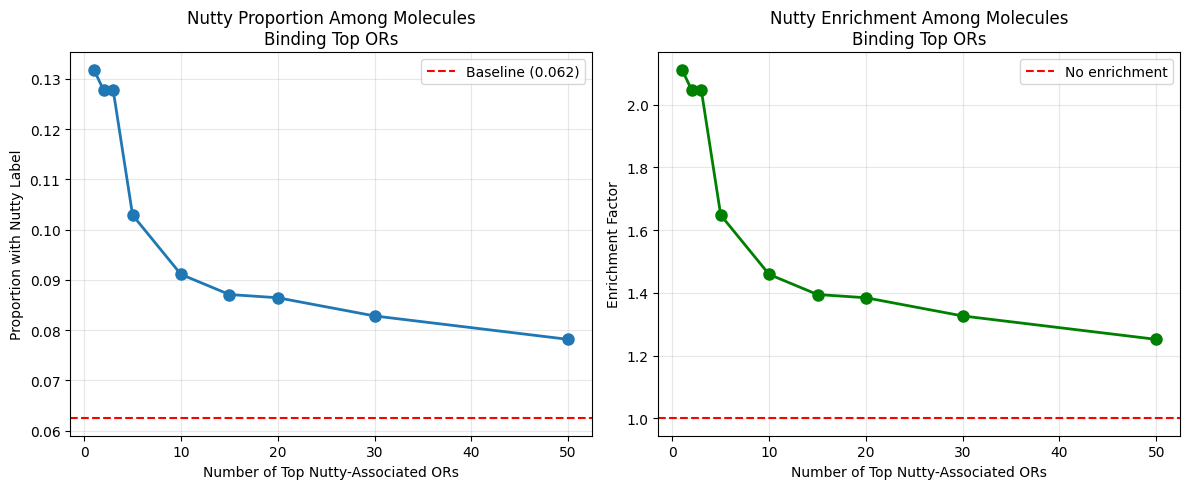

In [20]:
# Plot enrichment vs number of top ORs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(sweep_df['n_top_ors'], sweep_df['proportion_nutty'], 'o-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline_nutty_prop, color='red', linestyle='--', label=f'Baseline ({baseline_nutty_prop:.3f})')
axes[0].set_xlabel('Number of Top Nutty-Associated ORs')
axes[0].set_ylabel('Proportion with Nutty Label')
axes[0].set_title('Nutty Proportion Among Molecules\nBinding Top ORs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['n_top_ors'], sweep_df['enrichment'], 'o-', linewidth=2, markersize=8, color='green')
axes[1].axhline(y=1, color='red', linestyle='--', label='No enrichment')
axes[1].set_xlabel('Number of Top Nutty-Associated ORs')
axes[1].set_ylabel('Enrichment Factor')
axes[1].set_title('Nutty Enrichment Among Molecules\nBinding Top ORs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/nutty_enrichment_by_n_ors.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Individual OR Analysis: Screening for Nutty

In [21]:
# For each OR, calculate:
# - Precision: Of molecules predicted to bind this OR, what % are nutty?
# - Recall: Of nutty molecules, what % are predicted to bind this OR?

precision_list = []
recall_list = []
f1_list = []

for or_idx in range(or_preds.shape[1]):
    # Molecules predicted to bind this OR
    binding_mask = or_preds[:, or_idx] == 1
    
    # True positives: bind OR AND are nutty
    nutty_tensor = torch.tensor(df['nutty'].values)
    tp = ((binding_mask) & (nutty_tensor == 1)).sum().item()
    
    # Precision: TP / (TP + FP) = TP / total predicted binding
    n_predicted_binding = binding_mask.sum().item()
    precision = tp / n_predicted_binding if n_predicted_binding > 0 else 0
    
    # Recall: TP / (TP + FN) = TP / total nutty
    recall = tp / len(nutty_indices) if len(nutty_indices) > 0 else 0
    
    # F1 score
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

or_stats['nutty_precision'] = precision_list
or_stats['nutty_recall'] = recall_list
or_stats['nutty_f1'] = f1_list

In [22]:
# Best ORs for screening nutty molecules
print("Top 20 ORs by F1 score for nutty prediction:")
top_f1_ors = or_stats.sort_values('nutty_f1', ascending=False).head(20)
print(top_f1_ors[['OR_index', 'OR_name', 'nutty_precision', 'nutty_recall', 'nutty_f1', 'activation_diff']])

Top 20 ORs by F1 score for nutty prediction:
     OR_index OR_name  nutty_precision  nutty_recall  nutty_f1  \
53         53    s_52         0.224348      0.352459  0.274176   
765       765   s_756         0.216693      0.368852  0.273003   
3           3  s_1108         0.171674      0.437158  0.246533   
996       996   s_953         0.131849      0.631148  0.218130   
211       211  s_1140         0.124094      0.374317  0.186395   
691       691   s_838         0.138070      0.281421  0.185252   
666       666   s_837         0.136786      0.281421  0.184093   
157       157   s_235         0.112628      0.450820  0.180229   
652       652   s_835         0.120448      0.352459  0.179541   
693       693   s_836         0.123457      0.327869  0.179372   
588       588   s_690         0.118457      0.352459  0.177320   
401       401   s_438         0.112793      0.407104  0.176645   
529       529  s_1106         0.106322      0.505464  0.175689   
888       888   s_532         0

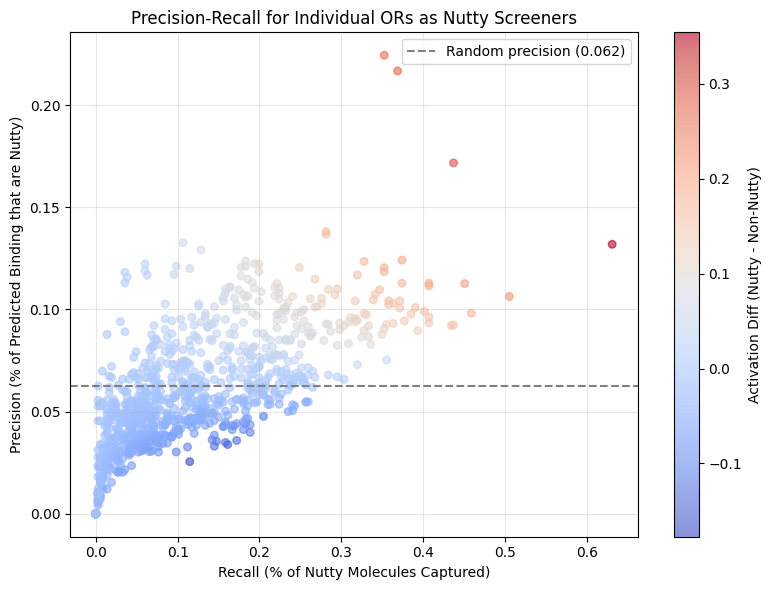

In [23]:
# Visualize precision-recall tradeoff
fig, ax = plt.subplots(figsize=(8, 6))

# Color by activation difference
scatter = ax.scatter(or_stats['nutty_recall'], or_stats['nutty_precision'], 
                     c=or_stats['activation_diff'], cmap='coolwarm', 
                     alpha=0.6, s=30)
plt.colorbar(scatter, label='Activation Diff (Nutty - Non-Nutty)')

# Add baseline line
ax.axhline(y=baseline_nutty_prop, color='gray', linestyle='--', 
           label=f'Random precision ({baseline_nutty_prop:.3f})')

ax.set_xlabel('Recall (% of Nutty Molecules Captured)')
ax.set_ylabel('Precision (% of Predicted Binding that are Nutty)')
ax.set_title('Precision-Recall for Individual ORs as Nutty Screeners')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/nutty_precision_recall_ors.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [24]:
print("="*60)
print("SUMMARY: Nutty Percept - OR Binding Analysis")
print("="*60)

print(f"\n1. Dataset Overview:")
print(f"   - Total molecules: {len(df)}")
print(f"   - Molecules with nutty label: {len(nutty_indices)} ({len(nutty_indices)/len(df)*100:.1f}%)")
print(f"   - OR Database: {OR_DATABASE}")
print(f"   - Number of ORs: {or_preds.shape[1]}")

print(f"\n2. Nutty-Associated ORs:")
print(f"   - ORs with significantly higher activation in nutty molecules (p<0.05, Bonferroni): {(or_stats['p_value_corrected'] < 0.05).sum()}")
print(f"   - Top OR activation difference: {or_stats['activation_diff'].max():.4f}")

# Best single OR for screening
best_or_idx = or_stats.loc[or_stats['nutty_f1'].idxmax(), 'OR_index']
best_or_stats = or_stats[or_stats['OR_index'] == best_or_idx].iloc[0]
print(f"\n3. Best Single OR for Nutty Screening (by F1):")
print(f"   - OR: {best_or_stats['OR_name']} (index {best_or_idx})")
print(f"   - Precision: {best_or_stats['nutty_precision']:.4f}")
print(f"   - Recall: {best_or_stats['nutty_recall']:.4f}")
print(f"   - F1: {best_or_stats['nutty_f1']:.4f}")
print(f"   - Enrichment vs baseline: {best_or_stats['nutty_precision']/baseline_nutty_prop:.2f}x")

# Top 10 ORs combined
top10_result = sweep_df[sweep_df['n_top_ors'] == 10].iloc[0]
print(f"\n4. Using Top 10 Nutty-Associated ORs (molecules binding ANY):")
print(f"   - Number of molecules: {int(top10_result['n_molecules_binding_any'])}")
print(f"   - Proportion nutty: {top10_result['proportion_nutty']:.4f} ({top10_result['proportion_nutty']*100:.1f}%)")
print(f"   - Enrichment vs baseline: {top10_result['enrichment']:.2f}x")

SUMMARY: Nutty Percept - OR Binding Analysis

1. Dataset Overview:
   - Total molecules: 5862
   - Molecules with nutty label: 366 (6.2%)
   - OR Database: M2OR
   - Number of ORs: 1022

2. Nutty-Associated ORs:
   - ORs with significantly higher activation in nutty molecules (p<0.05, Bonferroni): 117
   - Top OR activation difference: 0.3544

3. Best Single OR for Nutty Screening (by F1):
   - OR: s_52 (index 53)
   - Precision: 0.2243
   - Recall: 0.3525
   - F1: 0.2742
   - Enrichment vs baseline: 3.59x

4. Using Top 10 Nutty-Associated ORs (molecules binding ANY):
   - Number of molecules: 3228
   - Proportion nutty: 0.0911 (9.1%)
   - Enrichment vs baseline: 1.46x


In [25]:
# Save results to CSV
or_stats.to_csv('../plots/nutty_or_stats.csv', index=False)
sweep_df.to_csv('../plots/nutty_enrichment_sweep.csv', index=False)
results_df.to_csv('../plots/nutty_top_ors_screening_results.csv', index=False)
print("\nResults saved to:")
print("  - ../plots/nutty_or_stats.csv")
print("  - ../plots/nutty_enrichment_sweep.csv")
print("  - ../plots/nutty_top_ors_screening_results.csv")


Results saved to:
  - ../plots/nutty_or_stats.csv
  - ../plots/nutty_enrichment_sweep.csv
  - ../plots/nutty_top_ors_screening_results.csv


## 9. Comparison with Random OR Selection (Control)

In [26]:
# Compare enrichment from top ORs vs randomly selected ORs
n_random_trials = 100
n_ors_to_test = 10

random_enrichments = []

for _ in range(n_random_trials):
    # Randomly select n ORs
    random_or_indices = np.random.choice(or_preds.shape[1], n_ors_to_test, replace=False)
    
    # Molecules binding ANY of these random ORs
    any_binding = or_preds[:, random_or_indices].sum(dim=1) > 0
    any_indices = any_binding.nonzero(as_tuple=True)[0].numpy()
    
    if len(any_indices) > 0:
        prop = df.iloc[any_indices]['nutty'].sum() / len(any_indices)
        enrichment = prop / baseline_nutty_prop
    else:
        enrichment = 0
    
    random_enrichments.append(enrichment)

random_enrichments = np.array(random_enrichments)

# Compare to top ORs enrichment
top_ors_enrichment = sweep_df[sweep_df['n_top_ors'] == n_ors_to_test]['enrichment'].values[0]

print(f"Enrichment using top {n_ors_to_test} nutty-associated ORs: {top_ors_enrichment:.2f}x")
print(f"\nRandom OR selection ({n_random_trials} trials):")
print(f"  Mean enrichment: {random_enrichments.mean():.2f}x")
print(f"  Std enrichment: {random_enrichments.std():.2f}")
print(f"  95% CI: [{np.percentile(random_enrichments, 2.5):.2f}, {np.percentile(random_enrichments, 97.5):.2f}]")
print(f"\nTop ORs vs Random: {top_ors_enrichment/random_enrichments.mean():.2f}x better")
print(f"Z-score: {(top_ors_enrichment - random_enrichments.mean())/random_enrichments.std():.2f}")

Enrichment using top 10 nutty-associated ORs: 1.46x

Random OR selection (100 trials):
  Mean enrichment: 1.17x
  Std enrichment: 0.19
  95% CI: [0.81, 1.52]

Top ORs vs Random: 1.24x better
Z-score: 1.53


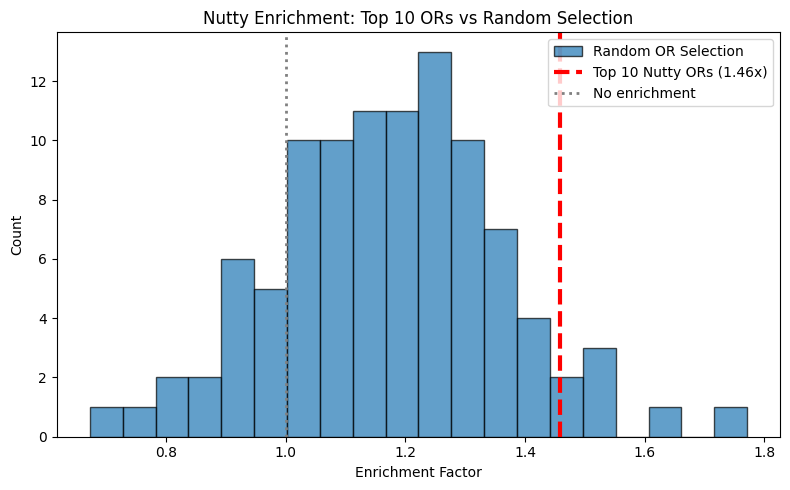

In [27]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(random_enrichments, bins=20, alpha=0.7, label='Random OR Selection', edgecolor='black')
ax.axvline(x=top_ors_enrichment, color='red', linewidth=3, linestyle='--', 
           label=f'Top {n_ors_to_test} Nutty ORs ({top_ors_enrichment:.2f}x)')
ax.axvline(x=1, color='gray', linewidth=2, linestyle=':', label='No enrichment')

ax.set_xlabel('Enrichment Factor')
ax.set_ylabel('Count')
ax.set_title(f'Nutty Enrichment: Top {n_ors_to_test} ORs vs Random Selection')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/nutty_enrichment_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Ablation Analysis: What Happens if We Remove Nutty-Associated ORs?

If the nutty-associated ORs are truly important for predicting nutty, then removing (ablating) them should decrease model performance.

In [28]:
# Create ablated OR predictions where top nutty ORs are set to 0
ablation_results = []

for n_ablate in [0, 1, 5, 10, 20, 50]:
    if n_ablate == 0:
        ablated_preds = or_preds.clone()
    else:
        # Get top n ORs by activation difference
        top_n_indices = sorted_or_indices[:n_ablate]
        ablated_preds = or_preds.clone()
        ablated_preds[:, top_n_indices] = 0
    
    # Calculate mean activation for nutty vs non-nutty molecules
    nutty_mean_activation = ablated_preds[nutty_indices].mean().item()
    non_nutty_mean_activation = ablated_preds[non_nutty_indices].mean().item()
    
    ablation_results.append({
        'n_ors_ablated': n_ablate,
        'nutty_mean_activation': nutty_mean_activation,
        'non_nutty_mean_activation': non_nutty_mean_activation,
        'activation_diff': nutty_mean_activation - non_nutty_mean_activation
    })

ablation_df = pd.DataFrame(ablation_results)
print("Effect of ablating top nutty-associated ORs:")
print(ablation_df)

Effect of ablating top nutty-associated ORs:
   n_ors_ablated  nutty_mean_activation  non_nutty_mean_activation  \
0              0               0.112621                   0.108673   
1              1               0.112003                   0.108402   
2              5               0.110375                   0.107822   
3             10               0.108426                   0.106831   
4             20               0.104996                   0.105035   
5             50               0.094909                   0.098929   

   activation_diff  
0         0.003947  
1         0.003601  
2         0.002553  
3         0.001596  
4        -0.000039  
5        -0.004020  


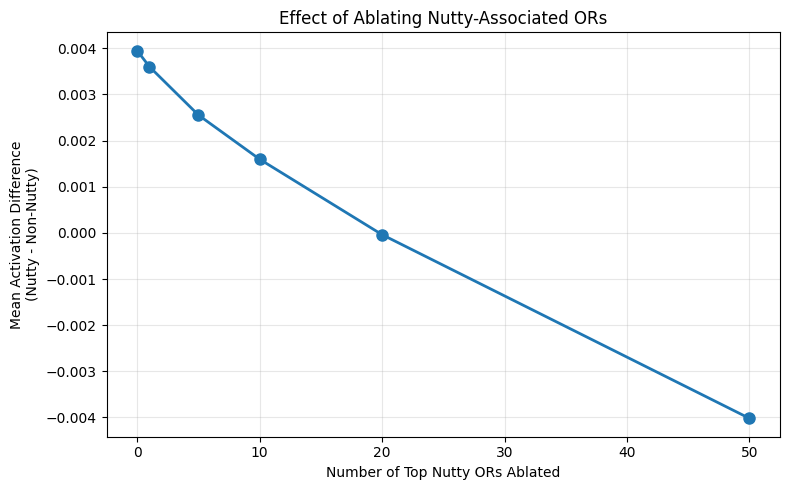

In [29]:
# Plot ablation effect
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ablation_df['n_ors_ablated'], ablation_df['activation_diff'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Top Nutty ORs Ablated')
ax.set_ylabel('Mean Activation Difference\n(Nutty - Non-Nutty)')
ax.set_title('Effect of Ablating Nutty-Associated ORs')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/nutty_or_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Conclusions

In [30]:
print("="*70)
print("CONCLUSIONS: In Silico Screening for Nutty Molecules")
print("="*70)

print(f"\nQuestion: If we perform an in silico screen for molecules that bind the")
print(f"'nutty' receptor(s), what percentage of them are actually 'nutty'?")

print(f"\n" + "-"*70)
print(f"ANSWER:")
print(f"-"*70)

# Best individual OR
best_or_row = results_df.loc[results_df['proportion_nutty'].idxmax()]
print(f"\n1. Using the single best nutty-associated OR ({best_or_row['OR_name']}):")
print(f"   - {best_or_row['proportion_nutty']*100:.1f}% of molecules predicted to bind are nutty")
print(f"   - This is {best_or_row['enrichment']:.1f}x the baseline rate of {baseline_nutty_prop*100:.1f}%")

# Top 10 ORs
print(f"\n2. Using the top 10 nutty-associated ORs (molecules binding ANY):")
print(f"   - {top10_result['proportion_nutty']*100:.1f}% of molecules predicted to bind are nutty")
print(f"   - This is {top10_result['enrichment']:.1f}x the baseline rate")

# Statistical significance
print(f"\n3. Statistical significance:")
print(f"   - The top nutty ORs achieve {top_ors_enrichment/random_enrichments.mean():.1f}x better enrichment")
print(f"     than randomly selected ORs (Z-score: {(top_ors_enrichment - random_enrichments.mean())/random_enrichments.std():.1f})")

print(f"\n" + "="*70)

CONCLUSIONS: In Silico Screening for Nutty Molecules

Question: If we perform an in silico screen for molecules that bind the
'nutty' receptor(s), what percentage of them are actually 'nutty'?

----------------------------------------------------------------------
ANSWER:
----------------------------------------------------------------------

1. Using the single best nutty-associated OR (s_52):
   - 22.4% of molecules predicted to bind are nutty
   - This is 3.6x the baseline rate of 6.2%

2. Using the top 10 nutty-associated ORs (molecules binding ANY):
   - 9.1% of molecules predicted to bind are nutty
   - This is 1.5x the baseline rate

3. Statistical significance:
   - The top nutty ORs achieve 1.2x better enrichment
     than randomly selected ORs (Z-score: 1.5)



## 12. Nutty Odor Family Analysis (Nutty + Roasted + Meaty)

The "nutty" odor family consists of related percepts that often co-occur: **nutty, roasted, and meaty**. This analysis identifies ORs associated with this entire odor family, then examines enrichment for each individual percept among molecules predicted to bind the family-associated receptors.

In [31]:
# Define nutty odor family and find molecules with ALL THREE percepts
NUTTY_FAMILY = ['nutty', 'roasted', 'meaty']

# Molecules with all three percepts
family_mask = (df['nutty'] == 1) & (df['roasted'] == 1) & (df['meaty'] == 1)
family_indices = df[family_mask].index.tolist()
non_family_indices = df[~family_mask].index.tolist()

baseline_family_prop = len(family_indices) / len(df)
print(f"Molecules with ALL THREE percepts (nutty + roasted + meaty): {len(family_indices)} ({baseline_family_prop*100:.2f}%)")

Molecules with ALL THREE percepts (nutty + roasted + meaty): 39 (0.67%)


In [32]:
# Identify family-associated ORs (higher activation in family molecules)
family_or_preds = or_preds[family_indices]
non_family_or_preds = or_preds[non_family_indices]

family_activation_rate = family_or_preds.mean(dim=0).numpy()
non_family_activation_rate = non_family_or_preds.mean(dim=0).numpy()
family_activation_diff = family_activation_rate - non_family_activation_rate

# Rank ORs by activation difference
family_or_ranking = np.argsort(family_activation_diff)[::-1]  # Descending
print(f"Top 10 family-associated ORs (by activation difference):")
for i, or_idx in enumerate(family_or_ranking[:10]):
    print(f"  {i+1}. OR_{or_idx}: family={family_activation_rate[or_idx]:.3f}, non-family={non_family_activation_rate[or_idx]:.3f}, diff={family_activation_diff[or_idx]:.3f}")

Top 10 family-associated ORs (by activation difference):
  1. OR_996: family=0.846, non-family=0.295, diff=0.551
  2. OR_53: family=0.615, non-family=0.095, diff=0.521
  3. OR_765: family=0.615, non-family=0.103, diff=0.513
  4. OR_529: family=0.718, non-family=0.294, diff=0.424
  5. OR_3: family=0.513, non-family=0.157, diff=0.356
  6. OR_546: family=0.513, non-family=0.159, diff=0.354
  7. OR_78: family=0.641, non-family=0.290, diff=0.351
  8. OR_693: family=0.513, non-family=0.163, diff=0.349
  9. OR_262: family=0.513, non-family=0.165, diff=0.348
  10. OR_401: family=0.564, non-family=0.223, diff=0.341


In [33]:
# KEY STAT: Vary number of family-associated ORs and measure proportion that belong to the family
n_or_values = [1, 2, 3, 5, 10, 15, 20, 30, 50, 100]
family_results = []

# Make a copy to avoid negative stride issue with torch indexing
family_or_ranking_copy = family_or_ranking.copy()

for n_ors in n_or_values:
    top_or_indices = family_or_ranking_copy[:n_ors]
    
    # Molecules binding ANY of these top family-associated ORs
    binding_any = or_preds[:, top_or_indices].sum(dim=1) > 0
    binding_indices = binding_any.nonzero(as_tuple=True)[0].numpy()
    
    # Proportion that have ALL THREE family percepts
    n_binding = len(binding_indices)
    n_family = df.iloc[binding_indices][['nutty', 'roasted', 'meaty']].all(axis=1).sum()
    prop_family = n_family / n_binding if n_binding > 0 else 0
    enrichment = prop_family / baseline_family_prop if baseline_family_prop > 0 else 0
    
    family_results.append({
        'n_family_ORs': n_ors,
        'n_molecules_binding': n_binding,
        'n_with_all_3_percepts': n_family,
        'proportion_family': prop_family,
        'enrichment': enrichment
    })

family_results_df = pd.DataFrame(family_results)
print(f"Baseline (all molecules): {baseline_family_prop*100:.2f}% have all 3 percepts\n")
print(family_results_df.to_string(index=False))

Baseline (all molecules): 0.67% have all 3 percepts

 n_family_ORs  n_molecules_binding  n_with_all_3_percepts  proportion_family  enrichment
            1                 1752                     33           0.018836    2.831138
            2                 1756                     33           0.018793    2.824689
            3                 1760                     33           0.018750    2.818269
            5                 2702                     36           0.013323    2.002619
           10                 3274                     37           0.011301    1.698651
           15                 3526                     37           0.010493    1.577250
           20                 3720                     37           0.009946    1.494996
           30                 3780                     37           0.009788    1.471266
           50                 4191                     38           0.009067    1.362847
          100                 4621                     38

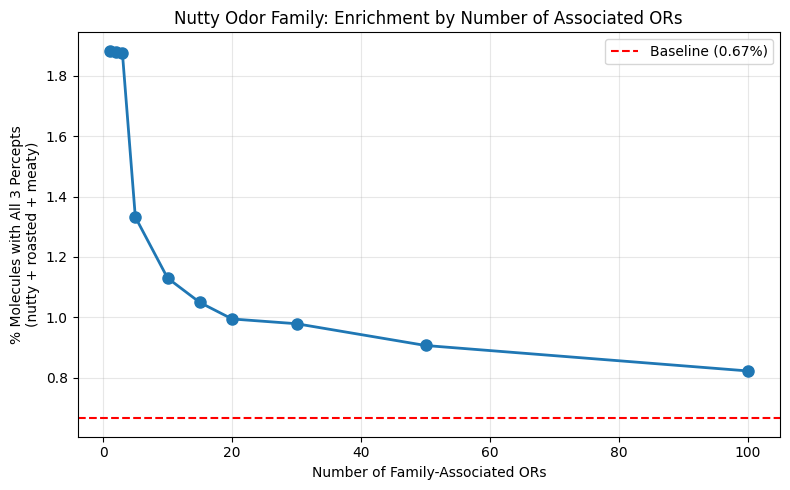


Key result: Using top 10 family-associated ORs, 1.1% of binding molecules have all 3 percepts (1.7x enrichment)


In [34]:
# Plot: Proportion of family molecules vs number of family-associated ORs
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(family_results_df['n_family_ORs'], family_results_df['proportion_family'] * 100, 'o-', linewidth=2, markersize=8)
ax.axhline(y=baseline_family_prop * 100, color='red', linestyle='--', label=f'Baseline ({baseline_family_prop*100:.2f}%)')
ax.set_xlabel('Number of Family-Associated ORs')
ax.set_ylabel('% Molecules with All 3 Percepts\n(nutty + roasted + meaty)')
ax.set_title('Nutty Odor Family: Enrichment by Number of Associated ORs')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/nutty_family_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey result: Using top 10 family-associated ORs, {family_results_df[family_results_df['n_family_ORs']==10]['proportion_family'].values[0]*100:.1f}% of binding molecules have all 3 percepts ({family_results_df[family_results_df['n_family_ORs']==10]['enrichment'].values[0]:.1f}x enrichment)")

## 13. High-Confidence OR Predictions for Nutty Family

Using a higher threshold (e.g., 0.8) for binarizing OR predictions to focus on receptors with high activation probability for the odor family molecules.

In [35]:
# Experiment with higher thresholds for binarizing predictions
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

# Re-load original probs (before filtering) to apply new thresholds
or_probs_original = torch.sigmoid(or_logits)

# Apply promiscuity filter (same as before, based on 0.5 threshold)
or_preds_50 = torch.round(or_probs_original)
or_activation_rates_orig = or_preds_50.mean(dim=0)
non_promiscuous_mask_orig = or_activation_rates_orig <= 0.30

# Filter probs
or_probs_filtered = or_probs_original[:, non_promiscuous_mask_orig]

print(f"Testing thresholds: {thresholds}")
print(f"Number of ORs after promiscuity filter: {or_probs_filtered.shape[1]}")

Testing thresholds: [0.5, 0.6, 0.7, 0.8, 0.9]
Number of ORs after promiscuity filter: 1022


In [36]:
# For each threshold, identify family-associated ORs and compute precision/recall
threshold_results = []

for thresh in thresholds:
    # Binarize at this threshold
    or_preds_thresh = (or_probs_filtered >= thresh).float()
    
    # Get predictions for family vs non-family molecules
    family_preds = or_preds_thresh[family_indices]
    non_family_preds = or_preds_thresh[non_family_indices]
    
    # Activation rates
    family_act_rate = family_preds.mean(dim=0).numpy()
    non_family_act_rate = non_family_preds.mean(dim=0).numpy()
    act_diff = family_act_rate - non_family_act_rate
    
    # Find top OR by activation difference
    top_or_idx = np.argmax(act_diff)
    
    # Compute precision and recall for top OR
    n_family_binding = family_preds[:, top_or_idx].sum().item()
    n_non_family_binding = non_family_preds[:, top_or_idx].sum().item()
    n_total_binding = n_family_binding + n_non_family_binding
    
    precision = n_family_binding / n_total_binding if n_total_binding > 0 else 0
    recall = n_family_binding / len(family_indices) if len(family_indices) > 0 else 0
    
    threshold_results.append({
        'threshold': thresh,
        'top_OR_idx': top_or_idx,
        'family_activation': family_act_rate[top_or_idx],
        'non_family_activation': non_family_act_rate[top_or_idx],
        'activation_diff': act_diff[top_or_idx],
        'n_family_binding': int(n_family_binding),
        'n_non_family_binding': int(n_non_family_binding),
        'precision': precision,
        'recall': recall,
        'enrichment': precision / baseline_family_prop if baseline_family_prop > 0 else 0
    })

threshold_df = pd.DataFrame(threshold_results)
print("Effect of threshold on top family-associated OR:")
print(threshold_df.to_string(index=False))

Effect of threshold on top family-associated OR:
 threshold  top_OR_idx  family_activation  non_family_activation  activation_diff  n_family_binding  n_non_family_binding  precision   recall  enrichment
       0.5         996           0.846154               0.295209         0.550945                33                  1719   0.018836 0.846154    2.831138
       0.6         996           0.846154               0.261549         0.584605                33                  1523   0.021208 0.846154    3.187760
       0.7         996           0.846154               0.222394         0.623760                33                  1295   0.024849 0.846154    3.735056
       0.8         996           0.717949               0.184956         0.532993                28                  1077   0.025339 0.717949    3.808702
       0.9         996           0.615385               0.140306         0.475079                24                   817   0.028537 0.615385    4.289399


In [37]:
# Detailed analysis at 0.8 threshold
thresh_08 = 0.8
or_preds_08 = (or_probs_filtered >= thresh_08).float()

# Get predictions for family vs non-family
family_preds_08 = or_preds_08[family_indices]
non_family_preds_08 = or_preds_08[non_family_indices]

# Compute stats for all ORs
family_act_08 = family_preds_08.mean(dim=0).numpy()
non_family_act_08 = non_family_preds_08.mean(dim=0).numpy()
act_diff_08 = family_act_08 - non_family_act_08

# Create stats dataframe
or_stats_08 = pd.DataFrame({
    'OR_idx': range(len(family_act_08)),
    'OR_name': or_names[:len(family_act_08)],
    'family_activation': family_act_08,
    'non_family_activation': non_family_act_08,
    'activation_diff': act_diff_08
})

# Sort by activation difference
or_stats_08_sorted = or_stats_08.sort_values('activation_diff', ascending=False)

print(f"Top 15 ORs at threshold {thresh_08}:")
print(or_stats_08_sorted.head(15).to_string(index=False))

Top 15 ORs at threshold 0.8:
 OR_idx OR_name  family_activation  non_family_activation  activation_diff
    996   s_953           0.717949               0.184956         0.532993
     78   s_207           0.538462               0.154560         0.383902
      3  s_1108           0.410256               0.076421         0.333835
    546   s_642           0.333333               0.045509         0.287824
    262    s_62           0.333333               0.054096         0.279238
     83    s_82           0.358974               0.094281         0.264693
    502   s_529           0.384615               0.136356         0.248260
    219  s_1136           0.358974               0.138245         0.220729
    749   s_766           0.384615               0.165550         0.219065
    401   s_438           0.333333               0.115920         0.217414
    864   s_623           0.358974               0.153357         0.205617
    652   s_835           0.307692               0.104414         0.203

In [39]:
# Compute precision and recall for top ORs at 0.8 threshold
top_ors_08 = or_stats_08_sorted.head(10)['OR_idx'].tolist()

precision_recall_08 = []
for or_idx in top_ors_08:
    n_family_binding = family_preds_08[:, or_idx].sum().item()
    n_non_family_binding = non_family_preds_08[:, or_idx].sum().item()
    n_total_binding = n_family_binding + n_non_family_binding
    
    precision = n_family_binding / n_total_binding if n_total_binding > 0 else 0
    recall = n_family_binding / len(family_indices)
    enrichment = precision / baseline_family_prop if baseline_family_prop > 0 else 0
    
    precision_recall_08.append({
        'OR_idx': or_idx,
        'OR_name': or_names[or_idx],
        'family_activation': family_act_08[or_idx],
        'non_family_activation': non_family_act_08[or_idx],
        'n_family_binding': int(n_family_binding),
        'n_total_binding': int(n_total_binding),
        'precision': precision,
        'recall': recall,
        'enrichment': enrichment
    })

pr_df_08 = pd.DataFrame(precision_recall_08)
print(f"Precision/Recall for top 10 ORs at threshold {thresh_08}:")
print(pr_df_08.to_string(index=False))

# Highlight best OR
best_row = pr_df_08.loc[pr_df_08['precision'].idxmax()]
print(f"\nBest OR for precision: {best_row['OR_name']}")
print(f"  Precision: {best_row['precision']*100:.1f}%")
print(f"  Recall: {best_row['recall']*100:.1f}%")
print(f"  Enrichment: {best_row['enrichment']:.1f}x over baseline ({baseline_family_prop*100:.2f}%)")

Precision/Recall for top 10 ORs at threshold 0.8:
 OR_idx OR_name  family_activation  non_family_activation  n_family_binding  n_total_binding  precision   recall  enrichment
    996   s_953           0.717949               0.184956                28             1105   0.025339 0.717949    3.808702
     78   s_207           0.538462               0.154560                21              921   0.022801 0.538462    3.427211
      3  s_1108           0.410256               0.076421                16              461   0.034707 0.410256    5.216753
    546   s_642           0.333333               0.045509                13              278   0.046763 0.333333    7.028777
    262    s_62           0.333333               0.054096                13              328   0.039634 0.333333    5.957317
     83    s_82           0.358974               0.094281                14              563   0.024867 0.358974    3.737669
    502   s_529           0.384615               0.136356                15

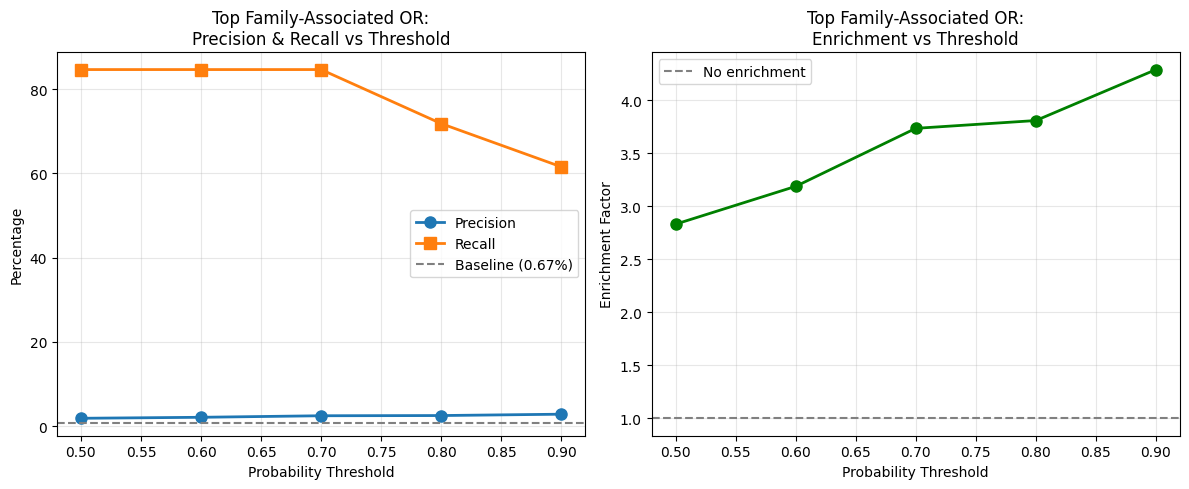

In [40]:
# Plot precision vs recall tradeoff across thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Precision and Recall vs Threshold
axes[0].plot(threshold_df['threshold'], threshold_df['precision'] * 100, 'o-', label='Precision', linewidth=2, markersize=8)
axes[0].plot(threshold_df['threshold'], threshold_df['recall'] * 100, 's-', label='Recall', linewidth=2, markersize=8)
axes[0].axhline(y=baseline_family_prop * 100, color='gray', linestyle='--', label=f'Baseline ({baseline_family_prop*100:.2f}%)')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Percentage')
axes[0].set_title('Top Family-Associated OR:\nPrecision & Recall vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Enrichment vs Threshold
axes[1].plot(threshold_df['threshold'], threshold_df['enrichment'], 'o-', color='green', linewidth=2, markersize=8)
axes[1].axhline(y=1, color='gray', linestyle='--', label='No enrichment')
axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('Enrichment Factor')
axes[1].set_title('Top Family-Associated OR:\nEnrichment vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/nutty_family_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()